<a href="https://colab.research.google.com/github/DeviHafida/dataset_jajanan/blob/main/UAS_JajananPasar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization, Input,
    RandomFlip, RandomRotation, RandomZoom, RandomContrast,
    Rescaling, RandomTranslation, RandomBrightness
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from google.colab import drive
drive.mount('/content/drive')

# ==================== KONFIGURASI ====================
DATASET_PATH = "/content/drive/MyDrive/dataset_balanced"
IMG_SIZE = 224
BATCH_SIZE = 16  # KECILKAN batch size untuk mengurangi overfitting
NUM_CLASSES = 6
KELAS = ['bingka', 'putu_ayu', 'cincin', 'bakpao', 'soes', 'amparan_tatak']

print("✅ Konfigurasi selesai!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Konfigurasi selesai!


[INFO] Mulai mengekstrak fitur dari gambar...
 📂 Memproses Kelas: amparan_tatak
 📂 Memproses Kelas: bakpao
 📂 Memproses Kelas: bingka
 📂 Memproses Kelas: cincin
 📂 Memproses Kelas: putu_ayu
 📂 Memproses Kelas: soes

[INFO] Memulai Evaluasi Skenario Eksperimen Lengkap...

🔬 TABEL REKAPITULASI SKOR AKURASI MULTI-SUBSET (DATA TEST, VAL, TRAIN)
No  Percobaan                Kernel    C     Gamma     Akurasi Train   Akurasi Val    Akurasi Test
--------------------------------------------------------------------------------------------------------------
1   Linear C=1               LINEAR    1     —         93.45%          90.56%         88.89%
2   RBF C=10 gamma=scale     RBF       10    scale     100.00%         94.44%         94.44%
3   RBF C=100 gamma=auto     RBF       100   auto      100.00%         96.11%         95.00%
--------------------------------------------------------------------------------------------------------------


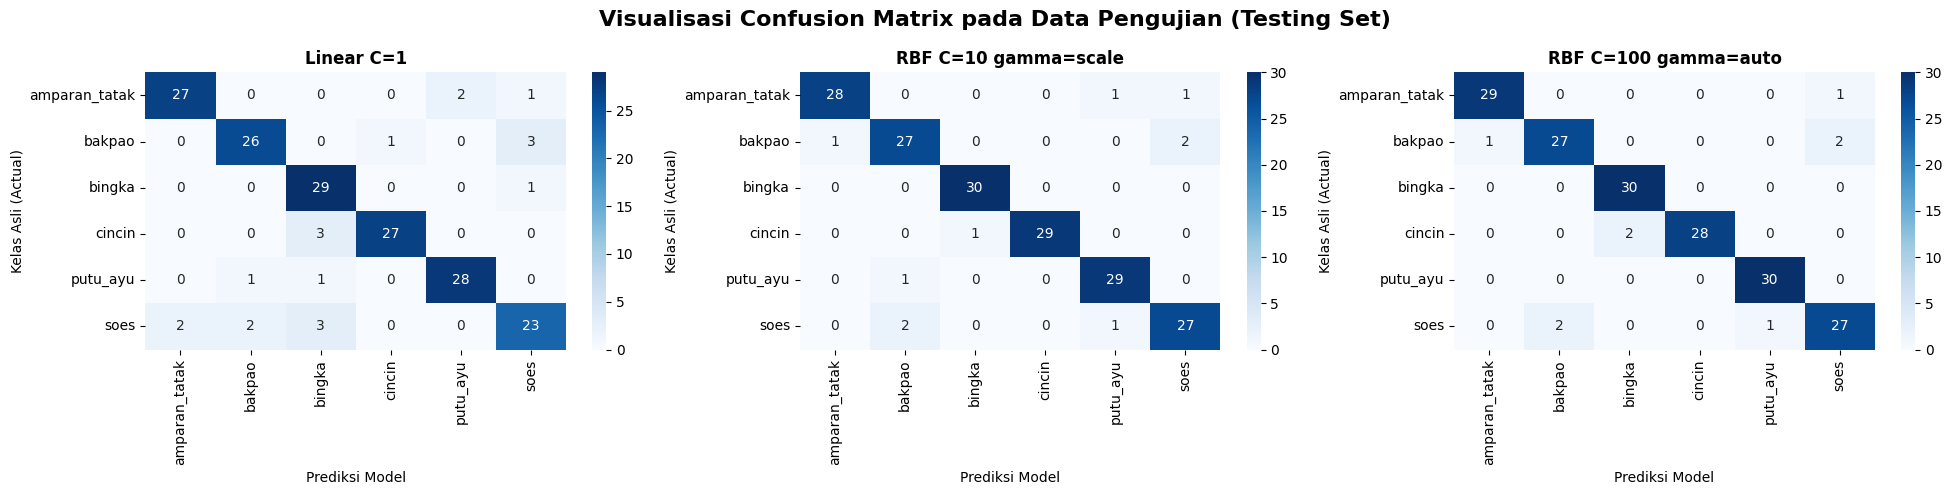

In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from skimage.feature import graycomatrix, graycoprops

# ======================================================================
# 1. KONFIGURASI & PARAMETER
# ======================================================================
DATASET_DIR = "/content/drive/MyDrive/dataset_balanced"
IMG_SIZE = (128, 128)

# ======================================================================
# 2. FUNGSI EKSTRAKSI FITUR (HSV & GLCM)
# ======================================================================
def extract_features(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    img_resized = cv2.resize(img, IMG_SIZE)

    # HSV (8 bin per channel -> Total 24 fitur)
    hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
    h_hist = cv2.calcHist([hsv], [0], None, [8], [0, 180])
    s_hist = cv2.calcHist([hsv], [1], None, [8], [0, 256])
    v_hist = cv2.calcHist([hsv], [2], None, [8], [0, 256])
    hsv_features = np.concatenate([h_hist, s_hist, v_hist]).flatten()
    hsv_features /= (hsv_features.sum() + 1e-6)

    # GLCM (5 properti x 4 arah -> Total 20 fitur)
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast').ravel()
    dissimilarity = graycoprops(glcm, 'dissimilarity').ravel()
    homogeneity = graycoprops(glcm, 'homogeneity').ravel()
    energy = graycoprops(glcm, 'energy').ravel()
    correlation = graycoprops(glcm, 'correlation').ravel()

    glcm_features = np.concatenate([contrast, dissimilarity, homogeneity, energy, correlation])

    # Total Kombinasi Fitur = 24 + 20 = 44 Fitur
    return np.concatenate([hsv_features, glcm_features])

# ======================================================================
# 3. LOADING DATASET & SPLITTING
# ======================================================================
print("[INFO] Mulai mengekstrak fitur dari gambar...")
X, y = [], []
class_names = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])

for class_label, class_name in enumerate(class_names):
    class_dir = os.path.join(DATASET_DIR, class_name)
    print(f" 📂 Memproses Kelas: {class_name}")
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        features = extract_features(img_path)
        if features is not None:
            X.append(features)
            y.append(class_label)

X, y = np.array(X), np.array(y)

# Split Data 70 / 15 / 15 secara Stratified
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Normalisasi Menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ======================================================================
# 4. RUNNING SKENARIO EKSPERIMEN (TRAIN, VAL, TEST)
# ======================================================================
experiments = [
    {"no": 1, "name": "Linear C=1",           "kernel": "linear", "C": 1,   "gamma": "—"},
    {"no": 2, "name": "RBF C=10 gamma=scale",   "kernel": "rbf",    "C": 10,  "gamma": "scale"},
    {"no": 3, "name": "RBF C=100 gamma=auto",   "kernel": "rbf",    "C": 100, "gamma": "auto"}
]

table_results = []
cms = {}

print("\n[INFO] Memulai Evaluasi Skenario Eksperimen Lengkap...")
for exp in experiments:
    # Inisialisasi Model SVM sesuai Skenario
    if exp["kernel"] == "linear":
        model = SVC(kernel='linear', C=exp["C"], random_state=42)
    else:
        model = SVC(kernel='rbf', C=exp["C"], gamma=exp["gamma"], random_state=42)

    # Pelatihan Model (Fitting)
    model.fit(X_train_scaled, y_train)

    # Prediksi untuk masing-masing subset data
    y_pred_train = model.predict(X_train_scaled)
    y_pred_val = model.predict(X_val_scaled)
    y_pred_test = model.predict(X_test_scaled)

    # Hitung Akurasi untuk setiap subset data
    acc_train = accuracy_score(y_train, y_pred_train) * 100
    acc_val = accuracy_score(y_val, y_pred_val) * 100
    acc_test = accuracy_score(y_test, y_pred_test) * 100

    # Simpan Hasil ke dalam list rekapitulasi
    table_results.append({
        "no": exp["no"],
        "name": exp["name"],
        "kernel": exp["kernel"].upper(),
        "C": exp["C"],
        "gamma": exp["gamma"],
        "acc_train": f"{acc_train:.2f}%",
        "acc_val": f"{acc_val:.2f}%",
        "acc_test": f"{acc_test:.2f}%"
    })

    # Menyimpan matriks konfusi untuk subset testing
    cms[exp["name"]] = confusion_matrix(y_test, y_pred_test)

# ======================================================================
# 5. CETAK TABEL REKAPITULASI SESUAI KETENTUAN LAPORAN
# ======================================================================
print("\n" + "="*110)
print("🔬 TABEL REKAPITULASI SKOR AKURASI MULTI-SUBSET (DATA TEST, VAL, TRAIN)")
print("="*110)
print(f"{'No':<4}{'Percobaan':<25}{'Kernel':<10}{'C':<6}{'Gamma':<10}{'Akurasi Train':<16}{'Akurasi Val':<15}{'Akurasi Test'}")
print("-"*110)
for r in table_results:
    print(f"{r['no']:<4}{r['name']:<25}{r['kernel']:<10}{r['C']:<6}{r['gamma']:<10}{r['acc_train']:<16}{r['acc_val']:<15}{r['acc_test']}")
print("-"*110)

# ======================================================================
# 6. PLOT CONFUSION MATRIX (VISUALISASI)
# ======================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Visualisasi Confusion Matrix pada Data Pengujian (Testing Set)', fontsize=16, fontweight='bold')

for i, (title, cm) in enumerate(cms.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Prediksi Model')
    axes[i].set_ylabel('Kelas Asli (Actual)')

plt.tight_layout()
plt.show()

[INFO] Mulai mengekstrak fitur dari gambar...
 Memproses Kelas: amparan_tatak
 Memproses Kelas: bakpao
 Memproses Kelas: bingka
 Memproses Kelas: cincin
 Memproses Kelas: putu_ayu
 Memproses Kelas: soes

[INFO] Memulai Evaluasi Metrik Lengkap...

🔬 TABEL PERBANDINGAN METRIK EVALUASI (DATA TEST)
No  Percobaan               Accuracy     Precision    Recall       F1-Score
-------------------------------------------------------------------------------------
1   Linear C=1              88.89 %      89.20 %      88.89 %      88.88 %
2   RBF C=10 gamma=scale    94.44 %      94.48 %      94.44 %      94.44 %
3   RBF C=100 gamma=auto    95.00 %      95.05 %      95.00 %      94.98 %
-------------------------------------------------------------------------------------


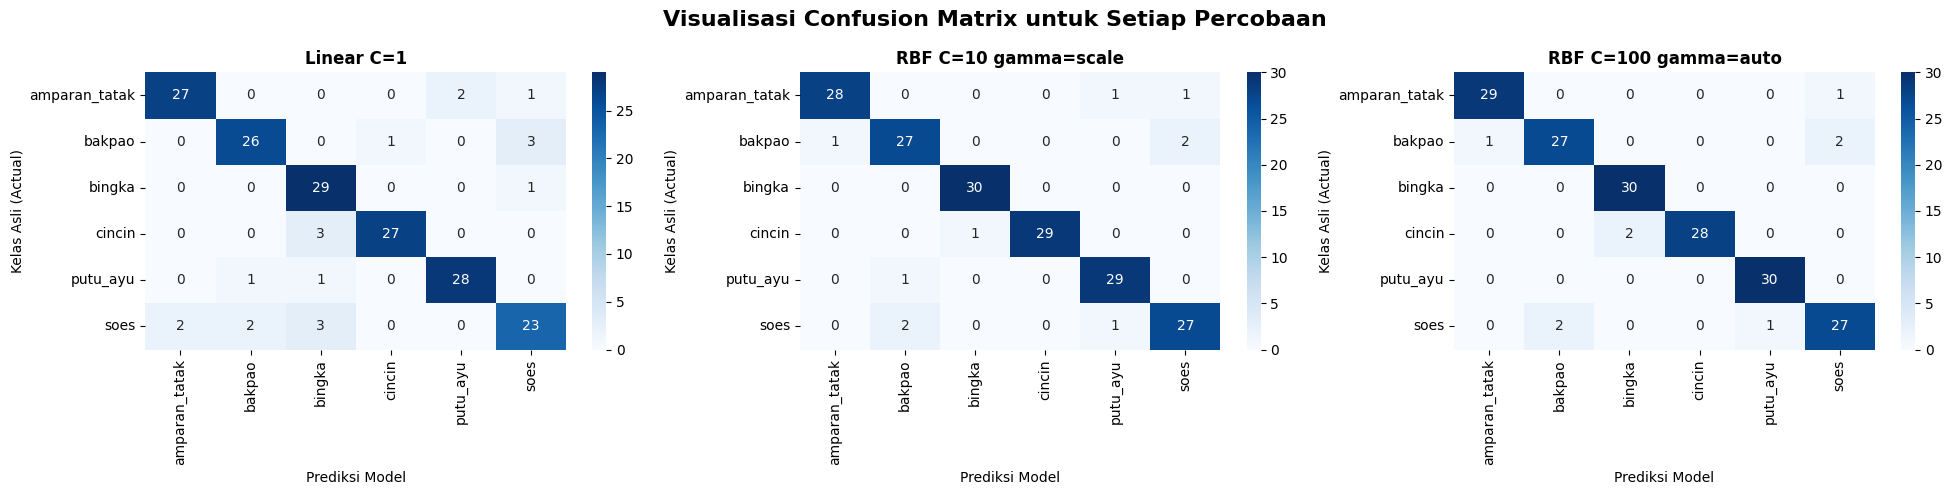

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from skimage.feature import graycomatrix, graycoprops # Added missing import

# ======================================================================
# 1. KONFIGURASI & PARAMETER
# ======================================================================
DATASET_DIR = "/content/drive/MyDrive/dataset_balanced"
IMG_SIZE = (128, 128)

# ======================================================================
# 2. FUNGSI EKSTRAKSI FITUR (HSV & GLCM)
# ======================================================================
def extract_features(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    img_resized = cv2.resize(img, IMG_SIZE)

    # HSV
    hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
    h_hist = cv2.calcHist([hsv], [0], None, [8], [0, 180])
    s_hist = cv2.calcHist([hsv], [1], None, [8], [0, 256])
    v_hist = cv2.calcHist([hsv], [2], None, [8], [0, 256])
    hsv_features = np.concatenate([h_hist, s_hist, v_hist]).flatten()
    hsv_features /= (hsv_features.sum() + 1e-6)

    # GLCM
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast').ravel()
    dissimilarity = graycoprops(glcm, 'dissimilarity').ravel()
    homogeneity = graycoprops(glcm, 'homogeneity').ravel()
    energy = graycoprops(glcm, 'energy').ravel()
    correlation = graycoprops(glcm, 'correlation').ravel()

    glcm_features = np.concatenate([contrast, dissimilarity, homogeneity, energy, correlation])
    return np.concatenate([hsv_features, glcm_features])

# ======================================================================
# 3. LOADING DATASET & BLENDING
# ======================================================================
print("[INFO] Mulai mengekstrak fitur dari gambar...")
X, y = [], []
class_names = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])

for class_label, class_name in enumerate(class_names):
    class_dir = os.path.join(DATASET_DIR, class_name)
    print(f" Memproses Kelas: {class_name}")
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        features = extract_features(img_path)
        if features is not None:
            X.append(features)
            y.append(class_label)

X, y = np.array(X), np.array(y)

# Split Data 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Normalisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ======================================================================
# 4. RUNNING EKSPERIMEN & PERHITUNGAN METRIK (DATA TEST)
# ======================================================================
experiments = [
    {"no": 1, "name": "Linear C=1",           "kernel": "linear", "C": 1,   "gamma": "scale"},
    {"no": 2, "name": "RBF C=10 gamma=scale",   "kernel": "rbf",    "C": 10,  "gamma": "scale"},
    {"no": 3, "name": "RBF C=100 gamma=auto",   "kernel": "rbf",    "C": 100, "gamma": "auto"}
]

table_results = []
cms = {} # Menyimpan confusion matrix tiap percobaan

print("\n[INFO] Memulai Evaluasi Metrik Lengkap...")
for exp in experiments:
    if exp["kernel"] == "linear":
        model = SVC(kernel='linear', C=exp["C"], random_state=42)
    else:
        model = SVC(kernel='rbf', C=exp["C"], gamma=exp["gamma"], random_state=42)

    model.fit(X_train_scaled, y_train)
    y_pred_test = model.predict(X_test_scaled)

    # Hitung Metrik Rata-rata (Macro Average) untuk Data Test
    acc = accuracy_score(y_test, y_pred_test) * 100
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_test, average='macro')

    # Simpan Hasil Metrik
    table_results.append({
        "no": exp["no"],
        "name": exp["name"],
        "acc": f"{acc:.2f} %",
        "prec": f"{prec*100:.2f} %",
        "rec": f"{rec*100:.2f} %",
        "f1": f"{f1*100:.2f} %"
    })

    # Simpan Confusion Matrix
    cms[exp["name"]] = confusion_matrix(y_test, y_pred_test)

# ======================================================================
# 5. CETAK TABEL REKAPITULASI METRIK
# ======================================================================
print("\n" + "="*85)
print("🔬 TABEL PERBANDINGAN METRIK EVALUASI (DATA TEST)")
print("="*85)
print(f"{'No':<4}{'Percobaan':<24}{'Accuracy':<13}{'Precision':<13}{'Recall':<13}{'F1-Score'}")
print("-"*85)
for r in table_results:
    print(f"{r['no']:<4}{r['name']:<24}{r['acc']:<13}{r['prec']:<13}{r['rec']:<13}{r['f1']}")
print("-"*85)

# ======================================================================
# 6. PLOT CONFUSION MATRIX (VISUALISASI)
# ======================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Visualisasi Confusion Matrix untuk Setiap Percobaan', fontsize=16, fontweight='bold')

for i, (title, cm) in enumerate(cms.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Prediksi Model')
    axes[i].set_ylabel('Kelas Asli (Actual)')

plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Konfigurasi selesai!
📂 Dataset path: /content/drive/MyDrive/dataset_balanced
📊 Jumlah kelas: 6
📋 Kelas: ['bingka', 'putu_ayu', 'cincin', 'bakpao', 'soes', 'amparan_tatak']

📂 Loading dataset dari folder...
✅ Load bingka: 200 gambar
✅ Load putu_ayu: 200 gambar
✅ Load cincin: 200 gambar
✅ Load bakpao: 200 gambar
✅ Load soes: 200 gambar
✅ Load amparan_tatak: 200 gambar

📊 Total data asli berhasil dimuat: 1200 gambar

📊 Membagi data menjadi 70 / 15 / 15 ...
📊 Subset Training   : 840 gambar
📊 Subset Validation : 180 gambar
📊 Subset Testing    : 180 gambar

🔄 Memproses standarisasi tensor untuk arsitektur MobileNetV2...
✅ Tahap Preprocessing aman dan selesai!

🧠 Menginisialisasi arsitektur MobileNetV2...

🚀 Memulai Training Tahap 1 (Feature Extraction - Base Layers Frozen)...
Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.7500 - loss: 0.6972 - va

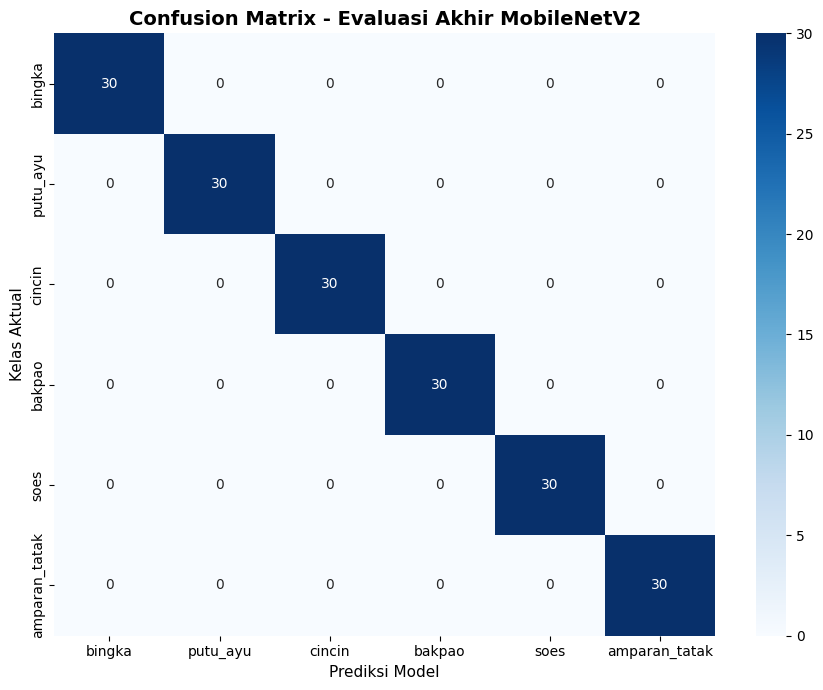

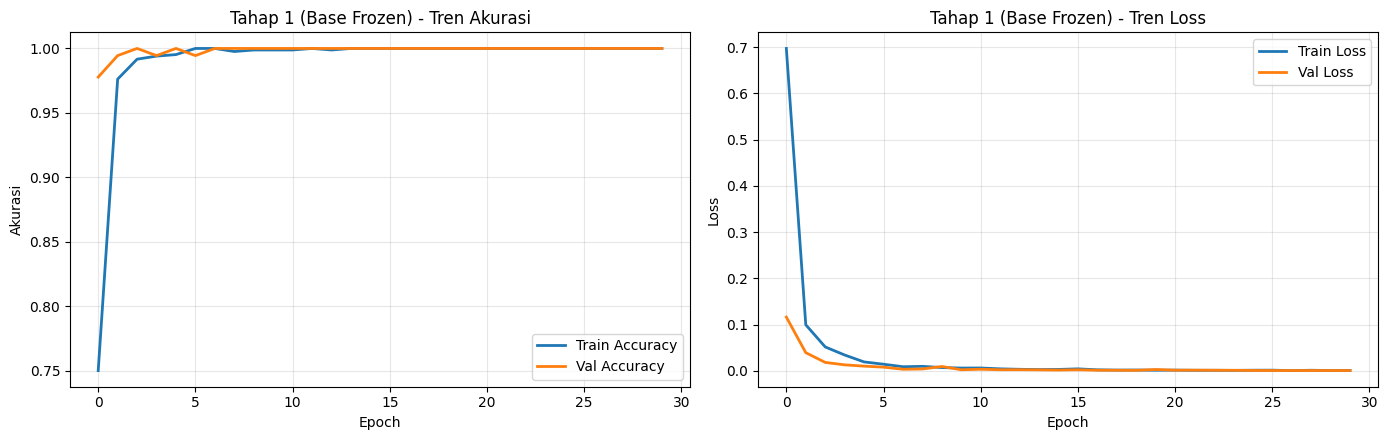

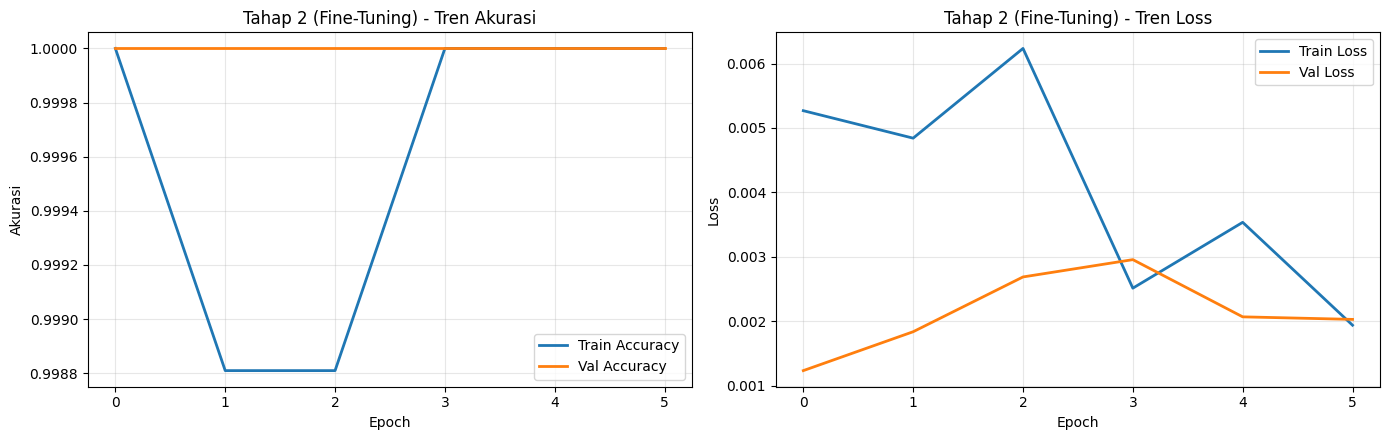


🎉 SELURUH PROSES BERHASIL DISELESAIKAN!


In [2]:
# ==================== 1. IMPORT LIBRARY ====================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
# PERBAIKAN: Menambahkan fungsi metrik yang kurang agar tidak NameError
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from google.colab import drive
drive.mount('/content/drive')

# ==================== 2. KONFIGURASI ====================
DATASET_PATH = "/content/drive/MyDrive/dataset_balanced"
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 6
KELAS = ['bingka', 'putu_ayu', 'cincin', 'bakpao', 'soes', 'amparan_tatak']

print("✅ Konfigurasi selesai!")
print(f"📂 Dataset path: {DATASET_PATH}")
print(f"📊 Jumlah kelas: {NUM_CLASSES}")
print(f"📋 Kelas: {KELAS}")

# ==================== 3. LOAD DATASET DARI FOLDER ====================
def load_dataset_from_folder(path, img_size):
    images = []
    labels = []

    for label, kelas in enumerate(KELAS):
        kelas_path = os.path.join(path, kelas)
        if not os.path.exists(kelas_path):
            print(f"⚠️ Folder {kelas_path} tidak ditemukan!")
            continue

        count = 0
        for img_name in os.listdir(kelas_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(kelas_path, img_name)
                img = cv2.imread(img_path)

                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (img_size, img_size))
                    images.append(img)
                    labels.append(label)
                    count += 1

        print(f"✅ Load {kelas}: {count} gambar")

    return np.array(images), np.array(labels)

print("\n📂 Loading dataset dari folder...")
X, y = load_dataset_from_folder(DATASET_PATH, IMG_SIZE)

print(f"\n📊 Total data asli berhasil dimuat: {len(X)} gambar")

# ==================== 5. SPLIT DATA & NORMALISASI AMAN ====================
print("\n📊 Membagi data menjadi 70 / 15 / 15 ...")
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"📊 Subset Training   : {len(X_train)} gambar")
print(f"📊 Subset Validation : {len(X_val)} gambar")
print(f"📊 Subset Testing    : {len(X_test)} gambar")

# OPTIMASI: MobileNetV2 bekerja paling baik langsung dengan fungsi preprocess_input bawaannya.
# Kita langsung gunakan data asli [0-255] ke fungsi preprocess_input agar nilainya tidak rusak/terlipat ganda saat di-run ulang.
print("\n🔄 Memproses standarisasi tensor untuk arsitektur MobileNetV2...")
X_train_mn = preprocess_input(X_train.astype('float32'))
X_val_mn = preprocess_input(X_val.astype('float32'))
X_test_mn = preprocess_input(X_test.astype('float32'))

print("✅ Tahap Preprocessing aman dan selesai!")

# ==================== 6. BUILD MOBILENETV2 ====================
def build_mobilenet_correct(input_shape=(224, 224, 3), num_classes=6):
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape,
        alpha=1.0
    )
    base_model.trainable = False  # Freeze arsitektur utama di tahap awal

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x) # Menurunkan sedikit tingkat dropout ke 0.4 agar model tidak terlalu pasif
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    return model, base_model

print("\n🧠 Menginisialisasi arsitektur MobileNetV2...")
model, base_model = build_mobilenet_correct()

# ==================== 8. KOMPILASI PHASE 1 ====================
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==================== 9. CALLBACKS ====================
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8, # Mempersingkat jeda tunggu agar tidak membuang waktu jika model stuck/overfitting
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

# ==================== 10. TRAINING PHASE 1 ====================
print("\n🚀 Memulai Training Tahap 1 (Feature Extraction - Base Layers Frozen)...")
history = model.fit(
    X_train_mn, y_train,
    validation_data=(X_val_mn, y_val),
    epochs=30, # 30 epoch sudah sangat cukup untuk mematangkan top layers
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

# ==================== 11. FINE-TUNING PHASE 2 ====================
print("\n🔧 Memulai Training Tahap 2 (Fine-tuning 5 Last Layers)...")
base_model.trainable = True
for layer in base_model.layers[:-5]:
    layer.trainable = False

# Gunakan LR yang sangat kecil agar bobot terlatih dari ImageNet tidak rusak mendadak
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    X_train_mn, y_train,
    validation_data=(X_val_mn, y_val),
    epochs=15,
    batch_size=BATCH_SIZE,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

# ==================== 12. EVALUASI LENGKAP ====================
print("\n📊 Menguji performa model terhadap testing subset...")
y_pred = model.predict(X_test_mn)
y_pred_classes = np.argmax(y_pred, axis=1)

acc = accuracy_score(y_test, y_pred_classes)
prec = precision_score(y_test, y_pred_classes, average='macro', zero_division=0)
rec = recall_score(y_test, y_pred_classes, average='macro')
f1 = f1_score(y_test, y_pred_classes, average='macro')

print("\n" + "="*50)
print(f"📊 RINGKASAN METRIK EVALUASI MOBILENETV2")
print("="*50)
print(f"   Accuracy  : {acc * 100:.2f} %")
print(f"   Precision : {prec * 100:.2f} %")
print(f"   Recall    : {rec * 100:.2f} %")
print(f"   F1-Score  : {f1 * 100:.2f} %")
print("-" * 50)

print("\n📋 Laporan Klasifikasi Detil:")
print(classification_report(y_test, y_pred_classes, target_names=KELAS))

# ==================== 13. CONFUSION MATRIX VISUALIZATION ====================
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=KELAS, yticklabels=KELAS)
plt.title('Confusion Matrix - Evaluasi Akhir MobileNetV2', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi Model', fontsize=11)
plt.ylabel('Kelas Aktual', fontsize=11)
plt.tight_layout()
plt.show()

# ==================== 14. PLOT TRAINING HISTORY ====================
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

    # Akurasi
    ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    ax1.set_title(f'{title} - Tren Akurasi')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Akurasi')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss
    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax2.set_title(f'{title} - Tren Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history, 'Tahap 1 (Base Frozen)')
plot_history(fine_tune_history, 'Tahap 2 (Fine-Tuning)')

print("\n🎉 SELURUH PROSES BERHASIL DISELESAIKAN!")